<a href="https://colab.research.google.com/github/manasvivasaikar30-dotcom/practice/blob/main/Tensorflow_hub_style_transfer_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import tensorflow as tf
import tensorflow_hub as hub

In [ ]:
print('Tensorflow version:', tf.__version__)
print('Tensorflow Hub version:', hub.__version__)

Tensorflow version: 2.20.0
Tensorflow Hub version: 0.16.1


In [ ]:
content_image_path = '/content/solar-system-illustration-16x9-1.jpg'
style_image_path = '/content/van gogh.jpg'

In [ ]:
def load_image(path, size = (256, 256)):
  image_path = tf.keras.utils.gets_file(path, path)
  image = tf.io.decode_image(tf.io.read_file(image_path), channels = 3, dtype = tf.float32[tf.newaxis,...])
  image = tf.image.resize(image, size, preserve_aspect_ratio = True)
  return image

In [ ]:
def load_image(path, size = (256, 256)):
  image_path = path
  image = tf.io.decode_image(tf.io.read_file(image_path), channels = 3, dtype = tf.float32)
  image = tf.image.resize(image, size, preserve_aspect_ratio = True)
  image = image[tf.newaxis, ...]
  return image

In [ ]:
content_image = load_image(content_image_path)
style_image = load_image(style_image_path)

In [ ]:
content_image.shape, style_image.shape

(TensorShape([1, 144, 256, 3]), TensorShape([1, 256, 144, 3]))

In [ ]:
def show_images(image, title = []):
  number_images = len(image)
  plt.figure(figsize = (12, 12))
  gs = gridspec.GridSpec(1, number_images)
  for i in range(number_images):
    plt.subplot(gs[i])
    plt.imshow(image[i][0])
    plt.title(title[i])
    plt.axis('off')
  plt.show()

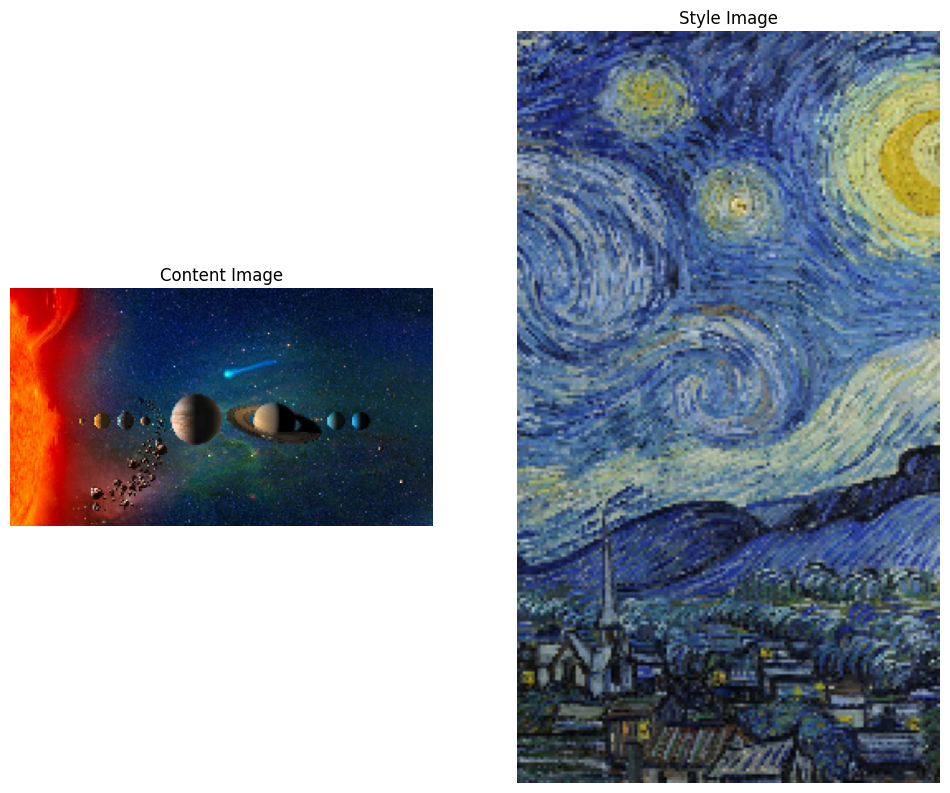

In [ ]:
show_images([content_image, style_image], ['Content Image', 'Style Image'])

In [ ]:
model_path = 'https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'
model = hub.load(model_path)

results = model(tf.constant(content_image), tf.constant(style_image))

results

[<tf.Tensor: shape=(1, 144, 256, 3), dtype=float32, numpy=
 array([[[[0.14842263, 0.30776992, 0.55689305],
          [0.17221926, 0.34093592, 0.61473644],
          [0.17696437, 0.34692106, 0.6171551 ],
          ...,
          [0.30542585, 0.56739366, 0.8504908 ],
          [0.2749845 , 0.58506656, 0.86483186],
          [0.25640857, 0.50585127, 0.8266281 ]],
 
         [[0.24604392, 0.4372782 , 0.70568854],
          [0.26062536, 0.47753394, 0.72919774],
          [0.28404132, 0.5138507 , 0.7493504 ],
          ...,
          [0.39962974, 0.66683716, 0.89469707],
          [0.4276543 , 0.7156588 , 0.91992664],
          [0.44819   , 0.69149125, 0.91136605]],
 
         [[0.2129079 , 0.3538142 , 0.63333386],
          [0.21924007, 0.3807069 , 0.6667108 ],
          [0.22153208, 0.39181224, 0.68446684],
          ...,
          [0.32307106, 0.5633652 , 0.8594264 ],
          [0.3678456 , 0.6186515 , 0.89194036],
          [0.40153456, 0.63025516, 0.89394563]],
 
         ...,
 
       

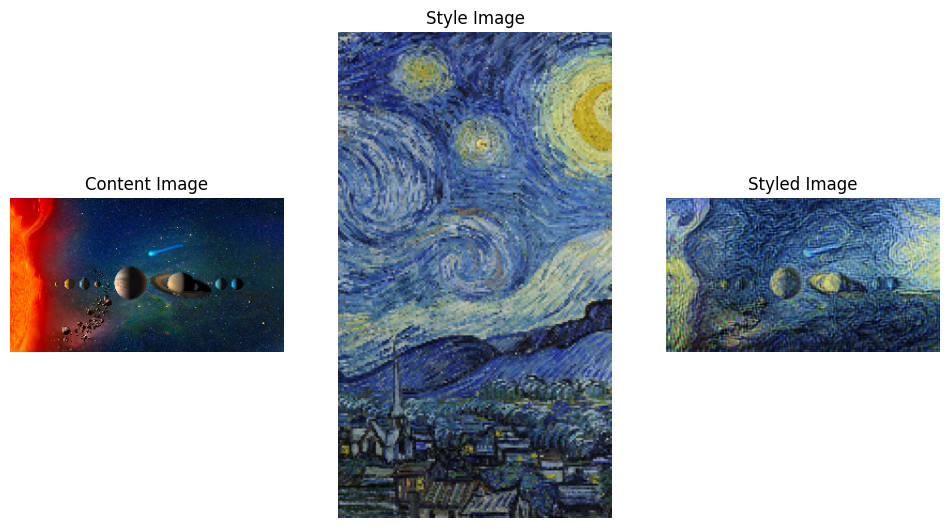

In [ ]:
show_images([content_image, style_image, results[0]], ['Content Image', 'Style Image', 'Styled Image'])